# Anna's data

In [3]:
# imports
from importlib import reload
from importlib.resources import files
import os
import numpy as np

from scipy.optimize import curve_fit
import xarray

import pandas
import seaborn as sns
from matplotlib import pyplot as plt

from scipy.interpolate import interp1d

from oceancolor.hydrolight import loisel23
from oceancolor.utils import plotting as oc_plotting

from cnmf.oceanography import utils as co_utils
from cnmf import nmf_imaging

# Load up

In [2]:
nobm_file = os.path.join(os.getenv('OS_COLOR'), 'data', 'NOBM', 'all_NOBM_OASIM_data_2020.nc')

In [6]:
nobm_xds = xarray.open_dataset(nobm_file, decode_times=False)

In [7]:
nobm_xds

<xarray.Dataset>
Dimensions:         (months: 12, lat: 234, lon: 288, wavelength: 501)
Coordinates:
  * months          (months) float32 0.0 1.0 2.0 3.0 4.0 ... 8.0 9.0 10.0 11.0
  * lat             (lat) float32 -84.0 -83.33 -82.67 -82.0 ... 70.0 70.67 71.33
  * lon             (lon) float32 -180.0 -178.8 -177.5 ... 176.2 177.5 178.8
  * wavelength      (wavelength) int64 250 251 252 253 254 ... 747 748 749 750
Data variables: (12/41)
    tot             (months, lat, lon) float32 ...
    chl             (months, lat, lon) float32 ...
    dia             (months, lat, lon) float32 ...
    coc             (months, lat, lon) float32 ...
    cya             (months, lat, lon) float32 ...
    din             (months, lat, lon) float32 ...
    ...              ...
    coc_a           (wavelength, months, lat, lon) float32 ...
    coc_bb          (wavelength, months, lat, lon) float32 ...
    cdoc_a          (wavelength, months, lat, lon) float32 ...
    det_a           (wavelength, months, lat, lon) float32 ...
    det_bb          (wavelength, months, lat, lon) float32 ...
    pic_bb          (wavelength, months, lat, lon) float32 ...

In [26]:
wave = nobm_xds.wavelength
wave

<xarray.DataArray 'wavelength' (wavelength: 501)>
array([250, 251, 252, ..., 748, 749, 750])
Coordinates:
  * wavelength  (wavelength) int64 250 251 252 253 254 ... 746 747 748 749 750

## Explore

In [10]:
rshape = nobm_xds.rrs.shape
rshape

(501, 12, 234, 288)

# Grab a random set of 500,000

In [13]:
Nspec = 500000
randi = np.random.choice(rshape[1]*rshape[2]*rshape[3], Nspec, replace=False)

## Unravel

In [14]:
jkl = np.unravel_index(randi, rshape[1:])

## Grab em

In [18]:
r_rrs = []
for ss in range(len(jkl[0])):
    r_rrs.append(nobm_xds.rrs.data[:,jkl[0][ss], jkl[1][ss], jkl[2][ss]])
#
r_rrs = np.array(r_rrs)

In [19]:
r_rrs.shape

(500000, 501)

# NMF me

## Scale

In [21]:
scaled_Rrs = r_rrs * 1e4

## Prep

In [22]:
new_spec, mask, err = co_utils.prep(scaled_Rrs, sigma=0.1)

## Do it

In [23]:
N_NMF = 4
outroot = 'Anna_scaledRrs'
normalize = True
#
comps = nmf_imaging.NMFcomponents(
    ref=new_spec, mask=mask, ref_err=err,
    n_components=N_NMF,
    path_save=outroot, oneByOne=True,
    normalize=normalize,
    seed=12345)

Building components one by one...
	 path_save provided, you might want to load data and continue previous component calculation
		 loading from Anna_scaledRrs_comp.npy for components.
		 Anna_scaledRrs_comp.npy does not exist, calculating from scratch.
	1 of 4
Took 0.098 minutes to reach current solution.
			 Calculation for 1 components done, overwriting raw 2D component matrix at Anna_scaledRrs_comp.npy
			 Calculation for 1 components done, overwriting raw 2D coefficient matrix at Anna_scaledRrs_coef.npy
	2 of 4
Took 0.043 minutes to reach current solution.
			 Calculation for 2 components done, overwriting raw 2D component matrix at Anna_scaledRrs_comp.npy
			 Calculation for 2 components done, overwriting raw 2D coefficient matrix at Anna_scaledRrs_coef.npy
	3 of 4
Took 0.043 minutes to reach current solution.
			 Calculation for 3 components done, overwriting raw 2D component matrix at Anna_scaledRrs_comp.npy
			 Calculation for 3 components done, overwriting raw 2D coefficient m

/home/xavier/Projects/Oceanography/python/cnmf/cnmf/nmf_imaging.py:377: RuntimeWarning: invalid value encountered in divide
  components = (components.T/np.sqrt(np.nansum(components**2, axis = (1, 2))).T).T


# Examine

In [24]:
M = np.load(outroot+'_comp.npy').T
coeff = np.load(outroot+'_coef.npy').T

In [28]:
M.shape

(4, 501)

## Plot

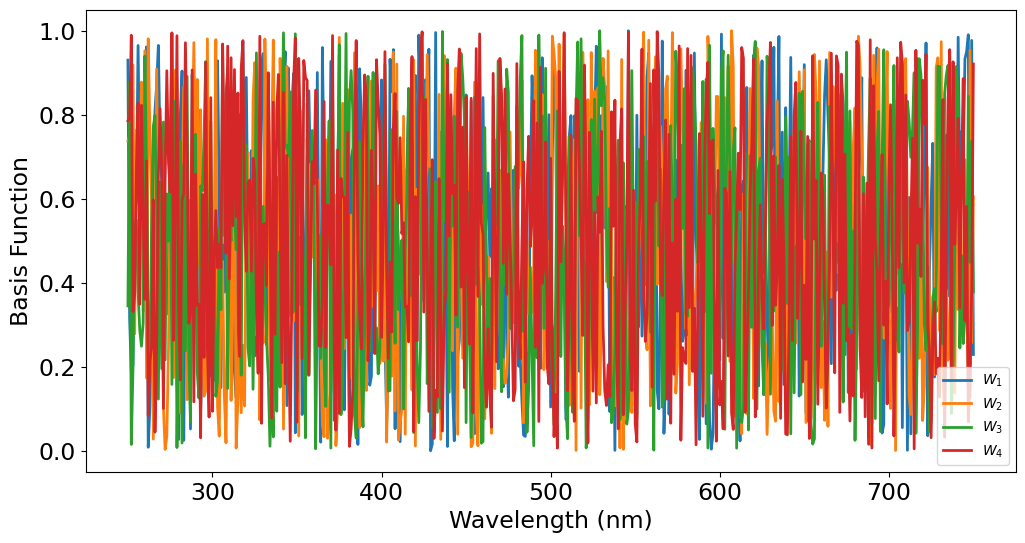

In [27]:
fig = plt.figure(figsize=(12,6))
ax = plt.gca()
#
for ii in range(N_NMF):
    # Step plot
    sns.lineplot(x=wave, y=M[ii],
                 label=r'$W_'+f'{ii+1}'+'$',
                 ax=ax, lw=2)#
# Pretty me up
ax.set_xlabel('Wavelength (nm)')
ax.set_ylabel('Basis Function')
oc_plotting.set_fontsize(ax, 17.)
#
plt.savefig('NMF_on_Rrs.png', dpi=300)
plt.show()